# 📊 AI 텍스트 탐지: 통계적 피처 분석

이 노트북에서는 Language Model을 활용하여 Human/AI 텍스트의 **통계적 지문(Statistical Signature)** 피처를 추출하고, 분포 차이를 시각화합니다.

**분석할 피처:**
- Token Entropy (토큰 엔트로피)
- Perplexity (복잡도)
- 반복 패턴 (N-gram Repetition Ratio)
- Logprob Tail Distribution

In [ ]:
# 필요 라이브러리 설치 (최초 실행 시)
# !pip install transformers torch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import seaborn as sns
import torch
from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Robust)
def set_korean_font():
    candidates = []
    system = platform.system()
    if system == 'Darwin':
        candidates = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic']
    elif system == 'Windows':
        candidates = ['Malgun Gothic', 'Dotum', 'Gulim']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'NanumMyeongjo']
    available_fonts = set([f.name for f in fm.fontManager.ttflist])
    for font in candidates:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f"✅ 한글 폰트 설정: {font}")
            return
    for f in available_fonts:
        if 'Nanum' in f or 'Gothic' in f:
            plt.rcParams['font.family'] = f
            plt.rcParams['axes.unicode_minus'] = False
            print(f"✅ 한글 폰트 설정: {f}")
            return
    print("⚠️ 한글 폰트를 찾지 못했습니다.")

set_korean_font()

# GPU 확인
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

✅ 한글 폰트 설정: AppleGothic
Using device: mps


## 1. 데이터 로드 및 균형 샘플링

In [2]:
# 데이터 로드
data_path = '/Users/youngjinson/Downloads/open/train.csv'
df = pd.read_csv(data_path)

# 균형 샘플링 (Human 500개, AI 500개 - 피처 추출이 무거우므로 적게 샘플링)
n_sample = 100  # 각 클래스당
df_human = df[df['generated'] == 0].sample(n=n_sample, random_state=42)
df_ai = df[df['generated'] == 1].sample(n=min(n_sample, len(df[df['generated']==1])), random_state=42)

sample_df = pd.concat([df_human, df_ai]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📊 샘플링 결과: Human {len(df_human)}개, AI {len(df_ai)}개")
print(f"총 {len(sample_df)}개 텍스트에서 피처 추출 예정")

📊 샘플링 결과: Human 100개, AI 100개
총 200개 텍스트에서 피처 추출 예정


## 2. Language Model 로드 (KoGPT2)

In [3]:
# KoGPT2 모델 로드 (한국어 GPT-2)
model_name = "skt/kogpt2-base-v2"
tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model.eval()
print(f"모델 로드 완료: {model_name}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료: skt/kogpt2-base-v2


## 3. 피처 추출 함수 정의

In [4]:
def get_ngram_repetition_ratio(text, n=3):
    """n-gram 반복 비율 계산. 반복이 많을수록 AI 가능성 높음."""
    words = text.split()
    if len(words) < n:
        return 0.0
    ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    counts = Counter(ngrams)
    repeated = sum(1 for c in counts.values() if c > 1)
    return repeated / len(counts)

def get_lm_features(text, max_length=256):
    """Language Model 기반 피처 추출: Perplexity, Entropy, Logprob 통계"""
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(device)
        
        if inputs['input_ids'].shape[1] < 2:
            return {'perplexity': np.nan, 'mean_entropy': np.nan, 'logprob_std': np.nan, 'low_prob_ratio': np.nan}
        
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])
            logits = outputs.logits[:, :-1, :]  # 마지막 토큰 제외
            labels = inputs["input_ids"][:, 1:]  # 첫 토큰 제외
            
            # Perplexity
            loss = outputs.loss.item()
            perplexity = np.exp(loss)
            
            # Token-level probabilities
            probs = torch.softmax(logits, dim=-1)  # (1, seq_len, vocab_size)
            
            # Mean Entropy per token
            entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)  # (1, seq_len)
            mean_entropy = entropy.mean().item()
            
            # Logprob of actual tokens
            log_probs = torch.log(probs + 1e-9)
            actual_logprobs = log_probs.gather(2, labels.unsqueeze(-1)).squeeze(-1)  # (1, seq_len)
            
            # Logprob 표준편차 (일관성 측정)
            logprob_std = actual_logprobs.std().item()
            
            # Low probability ratio (logprob < -5 인 토큰 비율)
            low_prob_ratio = (actual_logprobs < -5).float().mean().item()
            
        return {
            'perplexity': perplexity,
            'mean_entropy': mean_entropy,
            'logprob_std': logprob_std,
            'low_prob_ratio': low_prob_ratio
        }
    except Exception as e:
        return {'perplexity': np.nan, 'mean_entropy': np.nan, 'logprob_std': np.nan, 'low_prob_ratio': np.nan}

def extract_all_features(text):
    """모든 피처 추출"""
    features = get_lm_features(text)
    features['trigram_rep_ratio'] = get_ngram_repetition_ratio(text, n=3)
    features['bigram_rep_ratio'] = get_ngram_repetition_ratio(text, n=2)
    return features

## 4. 피처 추출 실행

In [5]:
# 피처 추출 (시간이 걸릴 수 있음)
print("🚀 피처 추출 시작... (샘플 수에 따라 5-10분 소요될 수 있습니다)")

features_list = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    features = extract_all_features(row['full_text'])
    features['generated'] = row['generated']
    features_list.append(features)

features_df = pd.DataFrame(features_list)
features_df['label'] = features_df['generated'].map({0: 'Human', 1: 'AI'})

print(f"\n✅ 피처 추출 완료! Shape: {features_df.shape}")
features_df.head()

🚀 피처 추출 시작... (샘플 수에 따라 5-10분 소요될 수 있습니다)


100%|██████████| 200/200 [00:42<00:00,  4.72it/s]



✅ 피처 추출 완료! Shape: (200, 8)


,perplexity,mean_entropy,logprob_std,low_prob_ratio,trigram_rep_ratio,bigram_rep_ratio,generated,label
0,194.258610,4.549955,3.549926,0.494118,0.011236,0.049407,0,Human
1,52.300789,3.020914,3.616106,0.356863,0.005882,0.030488,0,Human
2,113.846155,4.574265,3.174602,0.458824,0.011390,0.025822,0,Human
3,88.632998,4.332357,2.948958,0.380392,0.003782,0.024100,1,AI
4,76.841650,4.189429,2.833590,0.392157,0.000000,0.006667,1,AI


## 5. 분포 시각화

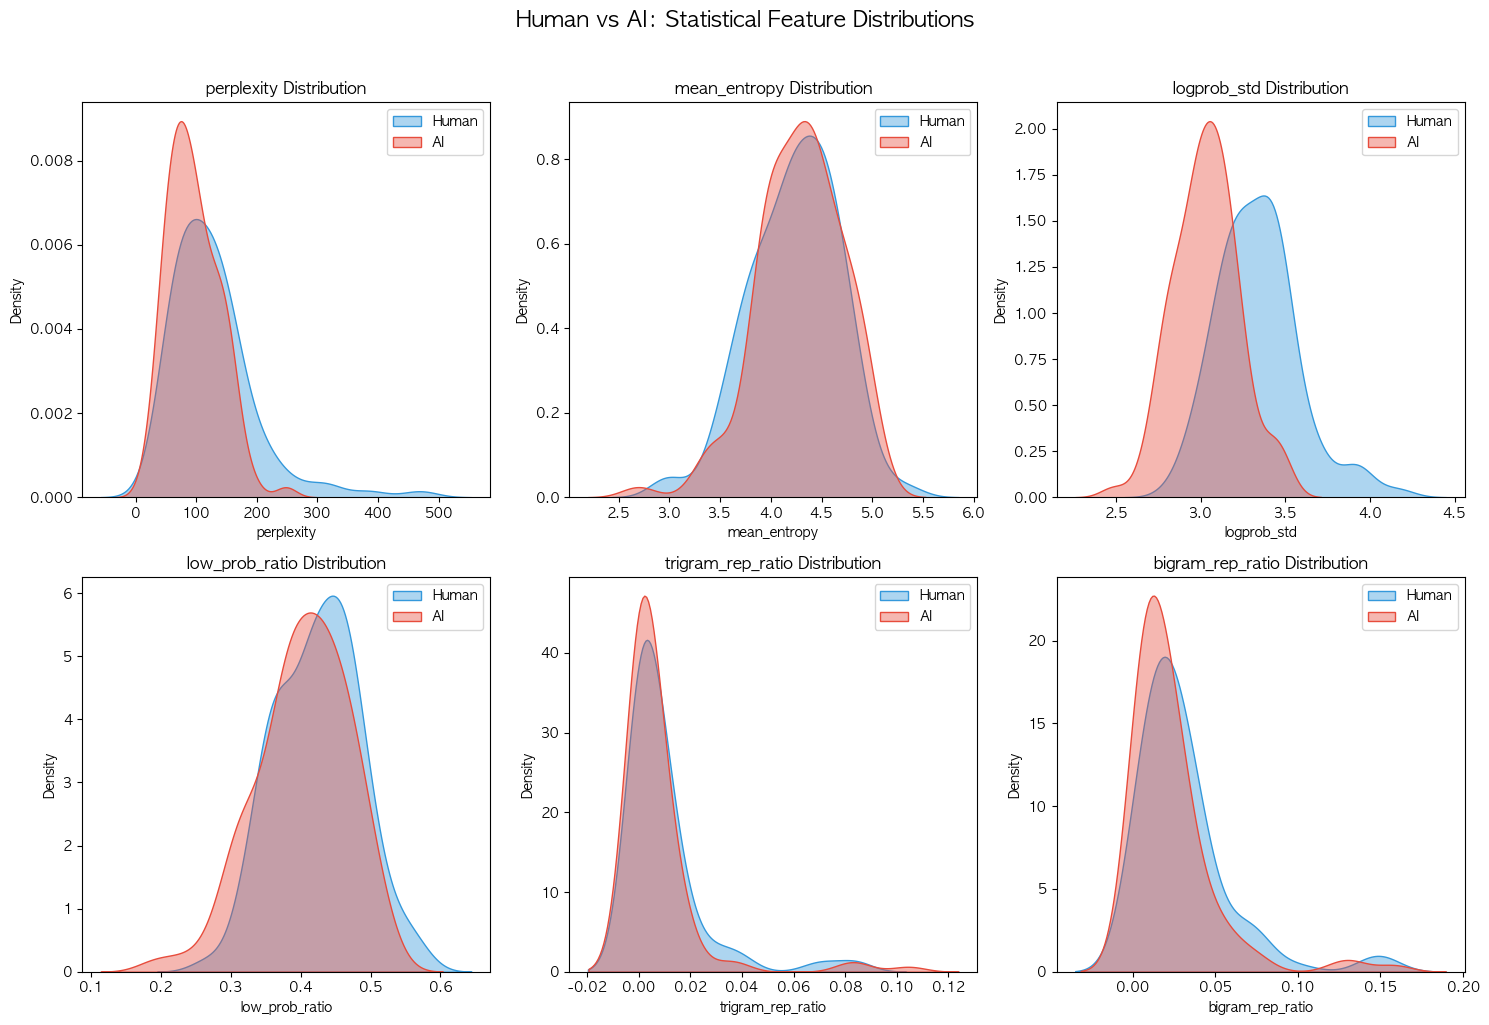

In [9]:
# 시각화할 피처 목록
feature_cols = ['perplexity', 'mean_entropy', 'logprob_std', 'low_prob_ratio', 'trigram_rep_ratio', 'bigram_rep_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    # 결측치 제거
    plot_data = features_df[['label', col]].dropna()
    
    # KDE plot
    for label, color in [('Human', '#3498db'), ('AI', '#e74c3c')]:
        subset = plot_data[plot_data['label'] == label][col]
        if len(subset) > 0:
            sns.kdeplot(subset, ax=ax, label=label, color=color, fill=True, alpha=0.4)
    
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Human vs AI: Statistical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. 통계적 요약

In [7]:
# Human vs AI 그룹별 평균 비교
summary = features_df.groupby('label')[feature_cols].agg(['mean', 'std'])
print("📊 Human vs AI 피처 통계 요약:\n")
print(summary.round(4))

📊 Human vs AI 피처 통계 요약:

      perplexity          mean_entropy         logprob_std          \
            mean      std         mean     std        mean     std   
label                                                                
AI       95.6341  42.3711       4.2861  0.4184      3.0325  0.1901   
Human   126.8902  70.9520       4.2315  0.4324      3.3357  0.2386   

      low_prob_ratio         trigram_rep_ratio         bigram_rep_ratio  \
                mean     std              mean     std             mean   
label                                                                     
AI            0.4031  0.0652            0.0071  0.0163           0.0233   
Human         0.4239  0.0600            0.0096  0.0165           0.0303   

               
          std  
label          
AI     0.0263  
Human  0.0291  


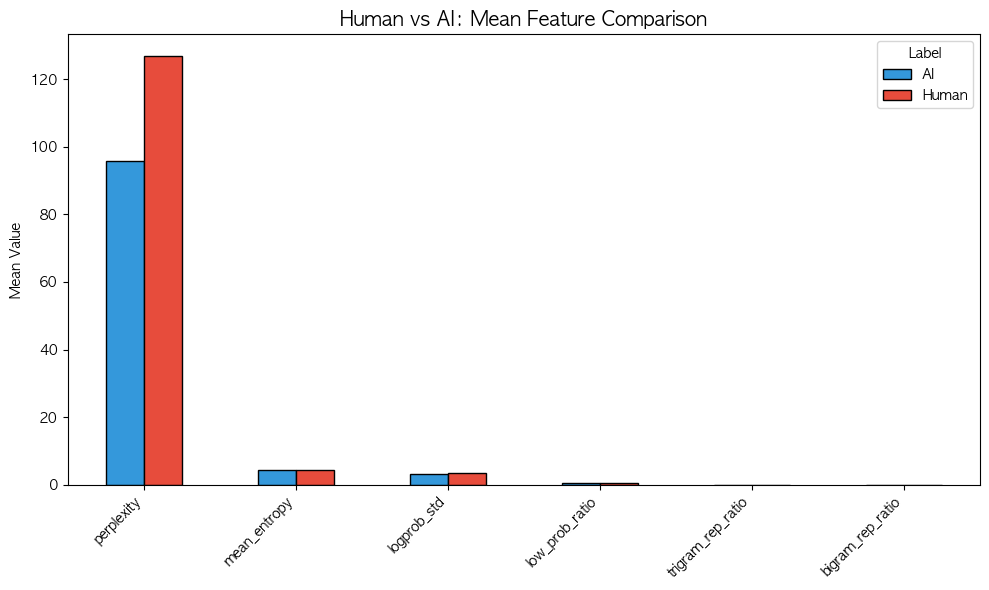

In [8]:
# 차이 시각화 (Bar plot)
mean_df = features_df.groupby('label')[feature_cols].mean().T

fig, ax = plt.subplots(figsize=(10, 6))
mean_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Human vs AI: Mean Feature Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend(title='Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()